# Interactive Visualization

This tutorial demonstrates the interactive visualization tools in `opensoundscape.visualization`.
These tools are designed for use in Jupyter or VS Code notebooks and provide:

- **`inspect`**: Display a grid of spectrograms with click-to-play audio
- **`annotate`**: Like `inspect`, but with toggle buttons to label clips in-place
- **`explore_features`**: Interactive scatter plot that shows spectrograms for selected points
- **`explore_histogram`**: Interactive histogram with per-label toggles and audio inspection

### Requirements

These functions require the optional `viz` dependencies:
```bash
pip install opensoundscape[viz]
```
This installs `ipywidgets` and `plotly`.

In [1]:
# if this is a Google Colab notebook, install opensoundscape in the runtime environment
if 'google.colab' in str(get_ipython()):
  %pip install "opensoundscape[viz]"

## Setup

Download a sample audio file and create a DataFrame of clips to work with.

In [ ]:
from opensoundscape import Audio
from opensoundscape.visualization import (
    inspect,
    annotate,
    explore_features,
    explore_histogram,
)
import opensoundscape as opso

import numpy as np
import pandas as pd
from pathlib import Path

In [3]:
# Download a 60-second birdsong recording
url = "https://tinyurl.com/birds60s"
audio = Audio.from_url(url)

# Save locally so visualization functions can load clips by file path
audio_path = Path("demo_audio.wav")
audio.save(audio_path)

print(f"Audio duration: {audio.duration:.1f}s, sample rate: {audio.sample_rate} Hz")

Audio duration: 60.0s, sample rate: 32000 Hz


In [ ]:
# Create a DataFrame of 3-second clips spanning the recording in 1-second steps
clip_df = opso.utils.make_clip_df(audio_path, clip_duration=3.0, clip_overlap=2.0)

clip_df.head()

Empty DataFrame
Columns: []
Index: [(demo_audio.wav, 0.0, 3.0), (demo_audio.wav, 1.0, 4.0), (demo_audio.wav, 2.0, 5.0), (demo_audio.wav, 3.0, 6.0), (demo_audio.wav, 4.0, 7.0)]

## `inspect`: View and listen to clips

`inspect` displays a grid of spectrograms. Click any spectrogram to play its audio.


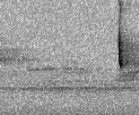
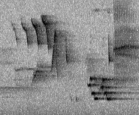
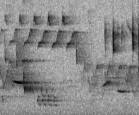
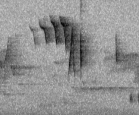
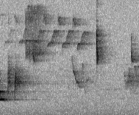
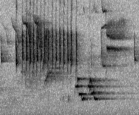
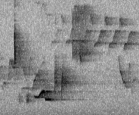
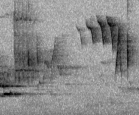
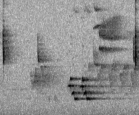
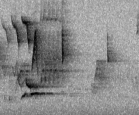

In [ ]:
widget = inspect(
    clip_df,
    N=10,
    bandpass_range=(500, 10000),
    cell_width=180,
    cell_height=150,
)

## `annotate`: Label clips interactively

`annotate` displays spectrograms with toggle buttons below each clip.
Clicking a button sets `clip_df.at[row_index, button_name] = True`;
clicking again sets it to `None`. The DataFrame is modified **in-place**.

In [ ]:
clips_to_label = clip_df.reset_index().sample(5)
widget = annotate(
    clips_to_label,
    annotation_buttons=["Wood Thrush", "Black-and-White Warbler"],
    N=8,
    bandpass_range=(500, 10000),
    dB_range=(-50, 0),
)

GridBox(children=(VBox(children=(HTML(value='<img src="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAJsAAACaC…

In [11]:
# After toggling some buttons above, check the annotations
clips_to_label.head()

,file,start_time,end_time,Wood Thrush,Black-and-White Warbler
47,demo_audio.wav,47.0,50.0,None,None
22,demo_audio.wav,22.0,25.0,None,None
20,demo_audio.wav,20.0,23.0,None,None
4,demo_audio.wav,4.0,7.0,True,None
26,demo_audio.wav,26.0,29.0,True,None


## Generate synthetic features for demo

For `explore_features` and `explore_histogram`, we need a DataFrame with
numeric feature columns, scores, and category labels. We generate random
values here for demonstration.

In [12]:
np.random.seed(42)

# Add random 2D features (e.g. from UMAP or PCA of audio embeddings)
clip_df["feature_x"] = np.random.randn(len(clip_df))
clip_df["feature_y"] = np.random.randn(len(clip_df))

# Add a random score (e.g. classifier confidence)
clip_df["score"] = np.random.uniform(0, 1, len(clip_df))

# Add a random category label
clip_df["category"] = np.random.choice(["song", "call", "noise"], size=len(clip_df))

clip_df.head()

feature_x  feature_y     score category
file           start_time end_time                                         
demo_audio.wav 0.0        3.0        0.496714  -0.479174  0.237638    noise
               1.0        4.0       -0.138264  -0.185659  0.728216    noise
               2.0        5.0        0.647689  -1.106335  0.367783     song
               3.0        6.0        1.523030  -1.196207  0.632306     song
               4.0        7.0       -0.234153   0.812526  0.633530    noise

## `explore_features`: Interactive scatter plot

`explore_features` shows a Plotly scatter plot of your data. Use box select
or lasso select to highlight points, and spectrograms for the selected clips
will appear below the plot.

Use the `color_col` argument to color points by a categorical column.

In [ ]:
fw = explore_features(
    clip_df,
    x_col="feature_x",
    y_col="feature_y",
    color_col="category",
    # kwargs below are passed to inspect() for selected points
    N=6,
    bandpass_range=(500, 10000),
    cell_width=150,
    cell_height=120,
)

Output()

Button(button_style='info', description='Inspect selected', icon='search', style=ButtonStyle())

Output()

## `explore_histogram`: Interactive histogram

`explore_histogram` displays overlaid histograms of a numeric column, split by
a label column. Each label gets a color-matched toggle button to show/hide its
histogram. Click "Inspect random selection" to view spectrograms of clips in
the current x-axis range.

In [ ]:
fw = explore_histogram(
    clip_df,
    value_col="score",
    label_col="category",
    bins=15,
    # kwargs below are passed to inspect()
    N=6,
    bandpass_range=(500, 10000),
    cell_width=150,
    cell_height=120,
)

    'data': [{'marker': {'color': 'rgb(127, 60, 141)'},
              'name': 'n…

## Clean up

Uncomment and run this cell to remove the temporary audio file created for this tutorial.

In [ ]:
# audio_path.unlink()
# print("Cleaned up temporary files.")